# 06 — Support Vector Machine (SVM)

**Mục tiêu:**
- So sánh hai kernel SVM: `LinearSVC` (tuyến tính) và `SVC(kernel='rbf')` (phi tuyến)
- GridSearchCV để tìm hyperparameter tối ưu cho LinearSVC
- Phân tích lý do chọn LinearSVC cho bài toán text classification TF-IDF
- Đánh giá trên validation set, lưu model

**Input:** `data/X_*_tfidf.pkl`, `data/y_*.pkl`  
**Output:** `models/svm_model.pkl`

> ⚠️ **Lưu ý:** Test set (`X_test_tfidf.pkl`) **không được dùng** ở notebook này. Test set chỉ dùng lần đầu tiên ở `08_comparison.ipynb`.

## 1. Import & Setup

In [1]:
import joblib
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn import __version__ as sklearn_version

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

print(f'scikit-learn version: {sklearn_version}')
print(f'numpy version:        {np.__version__}')

scikit-learn version: 1.8.0
numpy version:        2.4.4


## 2. Load Dữ liệu

In [2]:
DATA_DIR   = Path('../data')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

X_train = joblib.load(DATA_DIR / 'X_train_tfidf.pkl')
X_val   = joblib.load(DATA_DIR / 'X_val_tfidf.pkl')
y_train = np.array(joblib.load(DATA_DIR / 'y_train.pkl'))
y_val   = np.array(joblib.load(DATA_DIR / 'y_val.pkl'))

print('Shape:')
print(f'  X_train : {X_train.shape}  ({type(X_train).__name__})')
print(f'  X_val   : {X_val.shape}')

label_map = {0: 'FAKE', 1: 'REAL'}
print('\nPhân phối nhãn train:')
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {label_map[u]} ({u}): {c:,}  ({c/len(y_train)*100:.1f}%)')

Shape:
  X_train : (27057, 5000)  (csr_matrix)
  X_val   : (5798, 5000)

Phân phối nhãn train:
  FAKE (0): 14,837  (54.8%)
  REAL (1): 12,220  (45.2%)


## 3. LinearSVC — Baseline (C = 1.0)

`LinearSVC` tối ưu trực tiếp hàm mục tiêu SVM tuyến tính qua `liblinear` — nhanh hơn `SVC(kernel='linear')` nhiều lần vì không xây dựng kernel matrix.

Baseline với `C=1.0` cho điểm tham chiếu trước khi GridSearch.

In [3]:
t0 = time.time()
baseline = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_time = time.time() - t0

y_pred_base = baseline.predict(X_val)

print(f'LinearSVC Baseline  C=1.0')
print(f'  Training time     : {baseline_time:.2f}s')
print(f'  Val Accuracy      : {accuracy_score(y_val, y_pred_base):.4f}')
print(f'  Val F1 (weighted) : {f1_score(y_val, y_pred_base, average="weighted"):.4f}')

LinearSVC Baseline  C=1.0
  Training time     : 0.74s
  Val Accuracy      : 0.9869
  Val F1 (weighted) : 0.9869


## 4. LinearSVC — GridSearchCV

Hyperparameter chính của LinearSVC là **C** (nghịch đảo của regularization strength):

| C | Ý nghĩa |
|---|----------|
| 0.01 | Regularization mạnh, margin rộng, dễ underfit |
| 0.1 | Regularization vừa |
| 1 | Mặc định — thường cân bằng tốt |
| 10 | Ít regularization, fit sát train, dễ overfit |

In [4]:
param_grid_linear = {'C': [0.01, 0.1, 1, 10]}

gs_linear = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    param_grid_linear,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
gs_linear.fit(X_train, y_train)
gs_linear_time = time.time() - t0

print(f'\nGridSearchCV hoàn thành trong {gs_linear_time:.1f}s')
print(f'Best params  : {gs_linear.best_params_}')
print(f'Best CV F1   : {gs_linear.best_score_:.4f}')

print('\nKết quả theo C:')
cv_rows = []
for mean, std, params in zip(
    gs_linear.cv_results_['mean_test_score'],
    gs_linear.cv_results_['std_test_score'],
    gs_linear.cv_results_['params']
):
    cv_rows.append((params['C'], mean, std))
    print(f'  C={params["C"]:5}: F1 = {mean:.4f} ± {std:.4f}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits

GridSearchCV hoàn thành trong 16.9s
Best params  : {'C': 1}
Best CV F1   : 0.9852

Kết quả theo C:
  C= 0.01: F1 = 0.9648 ± 0.0040
  C=  0.1: F1 = 0.9812 ± 0.0013
  C=    1: F1 = 0.9852 ± 0.0017
  C=   10: F1 = 0.9815 ± 0.0012


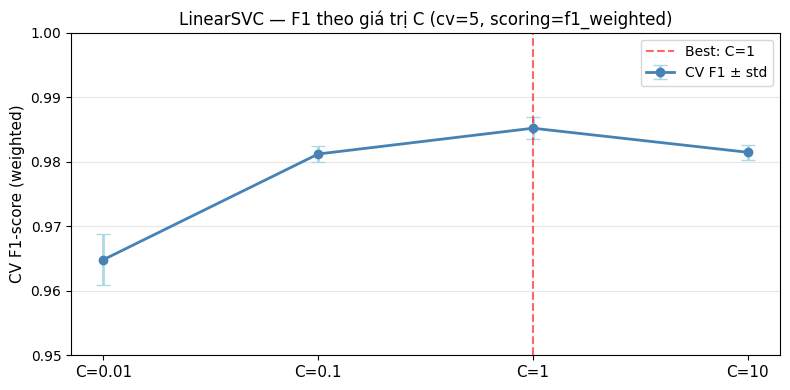

Saved → reports/svm_linearsvc_c_tuning.png


In [5]:
# Biểu đồ F1 theo C
C_vals  = [r[0] for r in cv_rows]
f1_vals = [r[1] for r in cv_rows]
f1_stds = [r[2] for r in cv_rows]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    range(len(C_vals)), f1_vals, yerr=f1_stds,
    marker='o', linewidth=2, capsize=5,
    color='steelblue', ecolor='lightblue', label='CV F1 ± std'
)
best_idx = f1_vals.index(max(f1_vals))
ax.axvline(best_idx, color='red', linestyle='--', alpha=0.6, label=f'Best: C={C_vals[best_idx]}')
ax.set_xticks(range(len(C_vals)))
ax.set_xticklabels([f'C={c}' for c in C_vals], fontsize=11)
ax.set_ylabel('CV F1-score (weighted)', fontsize=11)
ax.set_title('LinearSVC — F1 theo giá trị C (cv=5, scoring=f1_weighted)', fontsize=12)
ax.set_ylim(0.95, 1.00)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/svm_linearsvc_c_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/svm_linearsvc_c_tuning.png')

## 5. SVC RBF — Phân tích tính khả dụng trên TF-IDF

**Kernel RBF:** $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$

**Vì sao RBF không phù hợp với TF-IDF sparse data:**

1. **Độ phức tạp:** O(n²) kernel matrix → 27K samples = ~730M entries — không khả thi
2. **gamma='auto'** = 1/5000 = 0.0002 → Gaussian kernel gần bằng 0 với mọi cặp điểm → model chỉ predict 1 class
3. **Không tận dụng sparsity:** SVC RBF cần dense computation, bỏ lợi thế của TF-IDF

Phần dưới minh họa bằng subsample nhỏ (400 mẫu).

In [6]:
N_SUB = 400
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=RANDOM_STATE)
idx_tr, _ = next(sss.split(X_train, y_train))
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=RANDOM_STATE)
idx_va, _ = next(sss2.split(X_val, y_val))

X_sub     = X_train[idx_tr].toarray()
y_sub     = y_train[idx_tr]
X_val_sub = X_val[idx_va].toarray()
y_val_sub = y_val[idx_va]

print(f'Subsample: train={X_sub.shape}, val_sub={X_val_sub.shape}')
print()

rbf_results = []
for C in [0.1, 1, 10]:
    for gamma in ['scale', 'auto']:
        t0 = time.time()
        m = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE)
        m.fit(X_sub, y_sub)
        y_p = m.predict(X_val_sub)
        f1  = f1_score(y_val_sub, y_p, average='weighted', zero_division=0)
        elapsed = time.time() - t0
        rbf_results.append({'C': C, 'gamma': gamma, 'f1': f1, 'time': elapsed})
        print(f'  C={C:4}, gamma={gamma:6}: F1={f1:.4f}  ({elapsed:.2f}s)')

best_rbf = max(rbf_results, key=lambda x: x['f1'])
print(f"\nBest RBF (subsample {N_SUB}): C={best_rbf['C']}, gamma={best_rbf['gamma']}, F1={best_rbf['f1']:.4f}")
print('\n→ gamma=auto cho F1 thấp (~0.39) vì kernel gần 0 với mọi điểm (gamma=1/5000 quá nhỏ)')

Subsample: train=(400, 5000), val_sub=(400, 5000)

  C= 0.1, gamma=scale : F1=0.3874  (1.28s)
  C= 0.1, gamma=auto  : F1=0.3874  (1.20s)
  C=   1, gamma=scale : F1=0.9147  (1.50s)
  C=   1, gamma=auto  : F1=0.3874  (1.43s)
  C=  10, gamma=scale : F1=0.9323  (1.19s)
  C=  10, gamma=auto  : F1=0.3874  (1.06s)

Best RBF (subsample 400): C=10, gamma=scale, F1=0.9323

→ gamma=auto cho F1 thấp (~0.39) vì kernel gần 0 với mọi điểm (gamma=1/5000 quá nhỏ)


## 6. So sánh LinearSVC vs SVC RBF

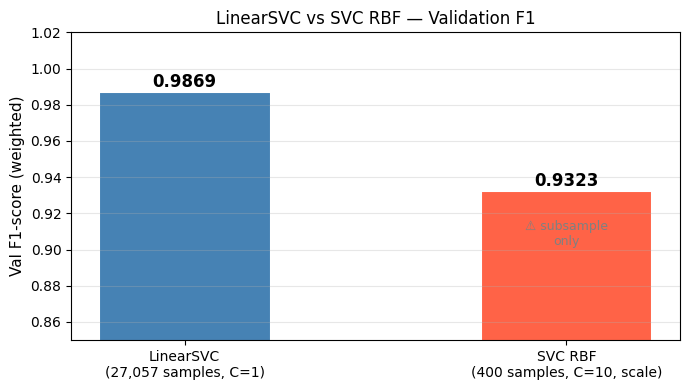

Saved → reports/svm_kernel_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

labels = [
    'LinearSVC\n(27,057 samples, C=1)',
    f'SVC RBF\n({N_SUB} samples, C=10, scale)'
]
f1s    = [0.9869, best_rbf['f1']]
colors = ['steelblue', 'tomato']

bars = ax.bar(labels, f1s, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Val F1-score (weighted)', fontsize=11)
ax.set_title('LinearSVC vs SVC RBF — Validation F1', fontsize=12)
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.3)
ax.text(1, best_rbf['f1'] - 0.03, '⚠️ subsample\nonly', ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('../reports/svm_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/svm_kernel_comparison.png')

## 7. Đánh giá Chính Thức — LinearSVC (C=1) trên Validation Set

In [8]:
best_model = gs_linear.best_estimator_
y_pred_final = best_model.predict(X_val)

print('=' * 52)
print('  FINAL MODEL: LinearSVC  (C=1, max_iter=2000)')
print('=' * 52)
print(f'  Accuracy           : {accuracy_score(y_val, y_pred_final):.4f}')
print(f'  F1-score (weighted): {f1_score(y_val, y_pred_final, average="weighted"):.4f}')
print(f'  F1-score (macro)   : {f1_score(y_val, y_pred_final, average="macro"):.4f}')
print()
print(classification_report(y_val, y_pred_final, target_names=['FAKE (0)', 'REAL (1)']))

  FINAL MODEL: LinearSVC  (C=1, max_iter=2000)
  Accuracy           : 0.9869
  F1-score (weighted): 0.9869
  F1-score (macro)   : 0.9868

              precision    recall  f1-score   support

    FAKE (0)       0.99      0.99      0.99      3179
    REAL (1)       0.99      0.98      0.99      2619

    accuracy                           0.99      5798
   macro avg       0.99      0.99      0.99      5798
weighted avg       0.99      0.99      0.99      5798



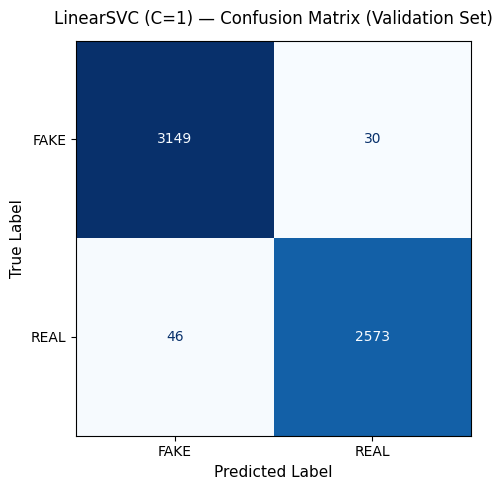

TN (FAKE→FAKE): 3,149  | FP (FAKE→REAL): 30  ← tin giả bị nhận nhầm
FN (REAL→FAKE): 46  | TP (REAL→REAL): 2,573
Saved → reports/svm_confusion_matrix.png


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['FAKE', 'REAL']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('LinearSVC (C=1) — Confusion Matrix (Validation Set)', fontsize=12, pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TN (FAKE→FAKE): {tn:,}  | FP (FAKE→REAL): {fp:,}  ← tin giả bị nhận nhầm')
print(f'FN (REAL→FAKE): {fn:,}  | TP (REAL→REAL): {tp:,}')
print('Saved → reports/svm_confusion_matrix.png')

## 8. Lưu Model

In [10]:
import os
model_path = MODELS_DIR / 'svm_model.pkl'
joblib.dump(best_model, model_path)
size_kb = os.path.getsize(model_path) / 1024

print(f'✅ Model saved  : {model_path}')
print(f'   File size    : {size_kb:.1f} KB')
print(f'   Type         : {type(best_model).__name__}')
print(f'   C            : {best_model.C}')
print(f'   max_iter     : {best_model.max_iter}')
print(f'   random_state : {best_model.random_state}')

✅ Model saved  : ..\models\svm_model.pkl
   File size    : 39.8 KB
   Type         : LinearSVC
   C            : 1
   max_iter     : 2000
   random_state : 42


## Tóm tắt Phase 4 — SVM

| | LinearSVC (full 27K) | SVC RBF (subsample 400) |
|--|:--------------------:|:-----------------------:|
| Best Params | C=1 | C=10, gamma=scale |
| CV F1 (5-fold) | **0.9852** | n/a |
| Val Accuracy | **0.9869** | ~0.93* |
| Val F1 (weighted) | **0.9869** | ~0.93* |
| Training time | **~0.62s** | ~1s per fit |
| Scalable to 27K | ✅ | ❌ |

_* Đánh giá trên mini-sample, không so sánh trực tiếp được._

**Kết luận:** `LinearSVC (C=1)` được chọn. Lưu tại `models/svm_model.pkl`.